In [1]:
import os, sys, time
from pathlib import Path
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import importlib

import torch
from torch.utils.data import DataLoader

import torch.nn as nn #?
from torch.functional import F #?
import torch.distributions as dist #?
from torch.utils.data import DataLoader, TensorDataset, random_split #?
import torchvision #?

import zuko

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor, TQDMProgressBar

sys.path.append('/n/home11/aakhmetzhanova/evidence-estimation-Astrid/')
from utils import datasets
import utils.resnet_cond as resnet
import utils.lightning_flows as LFlows
from utils import lightning_flows_density as LFlowsDensity


/n/home11/aakhmetzhanova/.conda/envs/ccl-env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: aakhmetzhanova. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /n/home11/aakhmetzhanova/.netrc
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or runnin

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Main code

In [3]:
field      = 'Mtot'
home_dir   = Path("/n/netscratch/dvorkin_lab/Lab/aakhmetzhanova/evidence-estimation-Astrid/") 
save_dir   = home_dir / f"trained_models/Maps_{field}/"


In [4]:
# Load summarizer and density estimator.
npe_k_cond = False
n_params   = 6
summary_dim = 40

checkpoint = save_dir / f'summarizer_scale_cond_{field}_Astrid/'
checkpoint = checkpoint / 'k_conv_lr_1e-4/checkpoints/best_val_loss.ckpt'
model      = LFlows.LightningFlowCond.load_from_checkpoint(checkpoint, 
                                                           device=device,
                                                           k_cond='conv',
                                                           npe_k_cond=npe_k_cond,
                                                           summary_dim=summary_dim, n_params=n_params,
                                                           model_name='resnet10t.c3_in1k',)
model.summarizer.eval();
model.density_estimator.eval();



In [6]:
# Load maps
minimum = np.array([0.1, 0.6, 0.25, 0.25, 0.5, 0.5])[:n_params] 
maximum = np.array([0.5, 1.0, 4.00, 4.00, 2.0, 2.0])[:n_params] 

splits    = 15
grid      = 256

maps_LH    = np.load(home_dir  / f'data/2D/Maps_{field}_Astrid_LH_z=0.00.npy').reshape(1000, -1, 1, grid, grid)[:, :splits]
maps_mean, maps_std = np.log10(maps_LH).mean(), np.log10(maps_LH).std()

params_LH   = np.loadtxt(home_dir / 'data/params_LH_Astrid.txt',)[:, :n_params] 
params_LH  = (params_LH - (minimum+maximum)/2)/((maximum - minimum)/2)   # rescale parameters
params_LH  = np.repeat(params_LH[:, None, :], splits, axis = 1) # reshape the parameters to match the shape of the maps


In [7]:
k_min, k_max   = 2., 45
k_smooth_array = np.logspace(np.log10(k_min), np.log10(k_max), num=10)

results_dir = Path("results/") #bias_vs_variance/")



In [8]:
from torch.utils.data import TensorDataset
from lampe.diagnostics.coverage import expected_coverage_mc
from tqdm import tqdm
from typing import Callable, Optional, Tuple
from torch import Tensor

In [10]:
def l2(x: Tensor, y: Tensor, axis=-1) -> Tensor:
    """
    Calculates the L2 distance between two tensors. Note, we cannot use the
    torch.nn.MSELoss function as this sums across the batch dimension AND the
    dimension given by <axis>. For tarp, we only require to sum across
    the <axis> dimension.

    Args:
        x (Tensor): The first tensor.
        y (Tensor): The second tensor.
        axis (int, optional): The axis along which to calculate the L2 distance.
                Defaults to -1.
    Returns:
        Tensor: A tensor containing the L2 distance between x and y along the
                specified axis.
    """
    return torch.sqrt(torch.sum((x - y) ** 2, dim=axis))

def get_tarp_references(thetas):
    """Returns reference points for the TARP diagnostic, sampled from a uniform."""

    # obtain min/max per dimension of theta
    lo = thetas.min(dim=0).values  # min for each theta dimension
    hi = thetas.max(dim=0).values  # max for each theta dimension

    refpdf = torch.distributions.Uniform(low=lo, high=hi)

    # sample one reference point for each entry in theta
    return refpdf.sample(torch.Size([thetas.shape[0]]))

In [11]:
def _run_tarp(
    posterior_samples: Tensor,
    thetas: Tensor,
    distance: Callable = l2,
    num_bins: Optional[int] = 30,
    z_score_theta: bool = False,
) -> Tuple[Tensor, Tensor]:
    """
    Estimates coverage of samples given true values theta with the TARP method.
    Reference: `Lemos, Coogan et al 2023 <https://arxiv.org/abs/2302.03026>`_

    The TARP diagnostic is a global diagnostic which can be used to check a
    trained posterior against a set of true values of theta.

    Args:
        samples: The predicted parameter samples to compute the coverage of,
                 these samples are expected to have shape
                 ``(num_samples, num_sims, num_dims)``. These are obtained by
                 sampling a trained posterior `num_samples` times. Multiple
                 (posterior) samples for one observation are encouraged.
        theta: The true parameter value theta. Theta is expected to
                 have shape ``(num_sims, num_dims)``.
        references: the reference points to use for the coverage regions, with
                shape ``(1, num_sims, num_dims)``, or ``None``.
                If ``None``, then reference points are chosen randomly from
                the unit hypercube over the parameter space given by theta.
                In other words, reference samples are drawn from the
                following ``Uniform(low=theta.min(dim=-1),high=theta.max(dim=-1))``.
        distance: the distance metric to use when computing the distance.
                Should be a callable function that accepts two tensors and
                computes the distance between them, e.g. given two tensors
                of shape ``(batch, 3)`` and ``(batch,3)``, this function should
                return ``(batch,1)`` distance values.
                Possible values: ``sbi.utils.metrics.l1`` or
                ``sbi.utils.metrics.l2``. ``l2`` is the default.
        num_bins: number of bins to use for the credibility values.
                If ``None``, then ``num_sims // 10`` bins are used.
        z_score_theta : whether to normalize parameters before coverage test.

    Returns:
        ecp: Expected coverage probability (``ecp``), see equation 4 of the paper
        alpha: grid of credibility values, see equation 2 of the paper

    """
    num_posterior_samples, num_tarp_samples, _ = posterior_samples.shape
    
    references = get_tarp_references(thetas)
    
    assert references.shape == thetas.shape, (
        "references must have the same shape as thetas"
    )

    if num_bins is None:
        num_bins = num_tarp_samples // 10

    if z_score_theta:
        lo = thetas.min(dim=0, keepdim=True).values  # min over batch
        hi = thetas.max(dim=0, keepdim=True).values  # max over batch
        posterior_samples = (posterior_samples - lo) / (hi - lo + 1e-10)
        thetas = (thetas - lo) / (hi - lo + 1e-10)

    # distances between references and samples
    sample_dists = distance(references, posterior_samples)

    # distances between references and true values
    theta_dists = distance(references, thetas)

    # compute coverage, f in algorithm 2
    coverage_values = (
        torch.sum(sample_dists < theta_dists, dim=0) / num_posterior_samples
    )
    hist, alpha_grid = torch.histogram(coverage_values, density=True, bins=num_bins)
    # calculate empirical CDF via cumsum and normalize
    ecp = torch.cumsum(hist, dim=0) / hist.sum()
    # add 0 to the beginning of the ecp curve to match the alpha grid
    ecp = torch.cat([Tensor([0]), ecp])

    return ecp, alpha_grid


In [12]:
def coverage_levels(log_p,
                    maps_set, params_set,
                    maps_mean, maps_std,
                    k_smooth_array,
                    n_samples=1024, params_idx=None, num_bins=50,
                    train_frac=0., valid_frac=0., test_frac=1.,
                    seed=1, batch_size=100):
    # compute params for IllustrisTNG
    levels_all_scales = []
    coverages_all_scales = []

    for i, k_smooth in enumerate(k_smooth_array):
        t1 = time.time()
        
        params_sampled = []
        params_true = []
        

        _, _, dset = datasets.create_datasets_maps(maps_set, params_set, 
                                                       train_frac, valid_frac, test_frac, 
                                                       seed=seed, rotations=False, 
                                                       smoothing=True, k_smooth=k_smooth,
                                                       k_min=k_min, k_max=k_max+1e-2,
                                                       normalize_k=True,
                                                       linear=False, log_scale=True, 
                                                       standardize=True, 
                                                       maps_mean=maps_mean, maps_std=maps_std,)
        dataloader  = DataLoader(dset, batch_size, shuffle = False, )

        for maps_test, params_test, k_test in dataloader:
            with torch.no_grad():
                maps_test    = maps_test.float().to(device=device)
                params_test  = params_test.float().to(device=device)
                k_test       = k_test.float().to(device=device)
                bs           = maps_test.shape[0]

                summaries_batch = model.summarizer([maps_test, k_test])
                if npe_k_cond:
                    summaries_batch  = torch.cat((summaries_batch, k_test), dim=1)
                
                params_sampled_batch = model.density_estimator(summaries_batch).sample((n_samples,))
                
                
                params_sampled.append(params_sampled_batch.cpu())
                params_true.append(params_test.cpu())
                
        
        params_sampled = torch.cat(params_sampled, dim=1)
        params_true    = torch.cat(params_true, dim=0)
        
        if params_idx is not None:
            params_sampled = params_sampled[:, :, params_idx]
            params_true    = params_true[:, params_idx]
        
        ecp, alpha = _run_tarp(params_sampled, params_true, num_bins=num_bins) 
        
        levels_all_scales.append(alpha)
        coverages_all_scales.append(ecp)
        
    return levels_all_scales, coverages_all_scales
    
    
    

In [13]:
log_p = lambda summaries: model.density_estimator(summaries)


In [14]:
levels_all, coverages_all = coverage_levels(log_p,
                maps_LH, params_LH, maps_mean, maps_std,
                k_smooth_array, 
                train_frac=0.9, valid_frac=0.05, test_frac=0.05,
                seed=1, batch_size=100,)



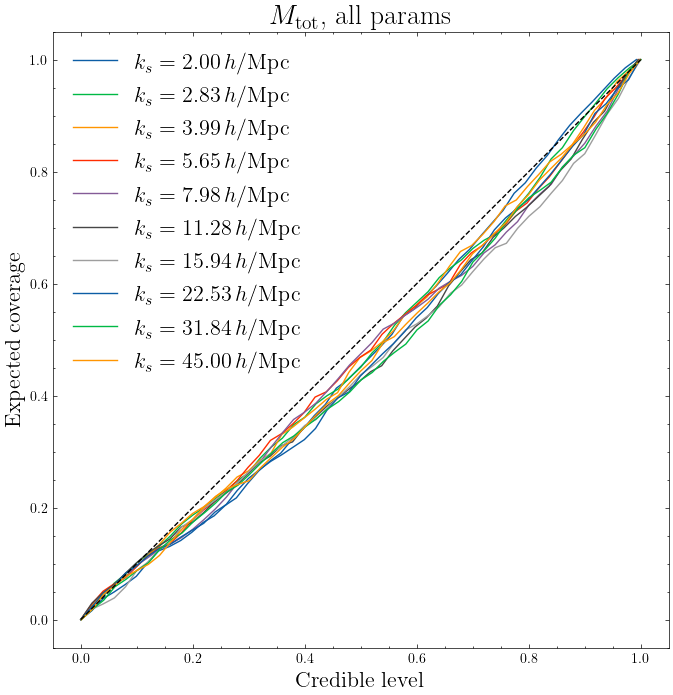

In [17]:
plt.style.use('science')
plt.figure(figsize=(8, 8))
plt.title(r'$M_{\mathrm{tot}}$' + ', all params', fontsize=20)
for i, (levels, coverages) in enumerate(zip(levels_all, coverages_all)):
    plt.plot(levels, coverages, label = r'$k_s = {:.2f} \, h/$'.format(k_smooth_array[i]) + 'Mpc')
plt.plot([0, 1], [0, 1], color='k', linestyle='--')
plt.xlabel(r'Credible level', fontsize=16)
plt.ylabel(r'Expected coverage', fontsize=16)
plt.legend(loc='best', fontsize=16)
plt.gca().set_aspect('equal')

In [18]:
levels_cosmo, coverages_cosmo = coverage_levels(log_p,
                maps_LH, params_LH, maps_mean, maps_std,
                k_smooth_array, params_idx=[0, 1], num_bins=50,
                train_frac=0.9, valid_frac=0.05, test_frac=0.05,
                seed=1, batch_size=100,)


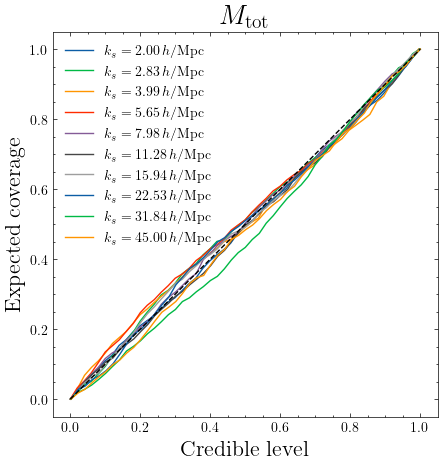

In [26]:
plt.style.use('science')
plt.figure(figsize=(5, 5))
plt.title(r'$M_{\mathrm{tot}}$', fontsize=20)
for i, (levels, coverages) in enumerate(zip(levels_cosmo, coverages_cosmo)):
    plt.plot(levels, coverages, label = r'$k_s = {:.2f} \, h/$'.format(k_smooth_array[i]) + 'Mpc')
plt.plot([0, 1], [0, 1], color='k', linestyle='--')
plt.xlabel(r'Credible level', fontsize=16)
plt.ylabel(r'Expected coverage', fontsize=16)
plt.legend(loc='best', fontsize=10)
plt.gca().set_aspect('equal')
plt.savefig(f'plots/5_coverage_{field}.pdf')